# Project plasma-cell states with starCAT

**Biology rationale.** Reference gene-expression programs provide a transferable framework for annotating functional plasma-cell states at single-cell resolution.

**Aim.** Fit starCAT to the plasma-cell reference programs and add discrete and continuous program scores to the query data.

**Data input.** `counts.h5ad`, `umap_usage_panels.pdf`, `cnmf_status_cat_umap.pdf`, `cnmf_status_cat_umap_split_by_orig_ident.pdf`, `cnmf_status_cat_annotation.csv`

**Data outputs.** `./cNMF_withoutIG_k=13/plasma_cNMF_3_withoutIG_k=13/plasma_cNMF_3_withoutIG_k=13.starcat_spectra.k_13.dt_2_0.txt`, `plasma_cnmf_3_usage_norm_withoutIG_k=13_allplasmacell.csv`, `plasma_cnmf_3_usage_norm_withoutIG_k=13.csv`

## 1. Packages and setup


In [1]:
import sys
from cnmf import cNMF
import os
import scanpy as sc
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from starcat import starCAT



In [2]:
tcat = starCAT(reference='./cNMF_withoutIG_k=13/plasma_cNMF_3_withoutIG_k=13/plasma_cNMF_3_withoutIG_k=13.starcat_spectra.k_13.dt_2_0.txt', 
               cachedir='./query_cNMF/cache')


Using user specified reference spectra file ./cNMF_withoutIG_k=13/plasma_cNMF_3_withoutIG_k=13/plasma_cNMF_3_withoutIG_k=13.starcat_spectra.k_13.dt_2_0.txt
No scores provided


In [3]:
tcat.ref

,PERM1,ISG15,TTLL10,TNFRSF18,TNFRSF4,TAS1R3,TMEM52,MMEL1,AL512413.1,MEGF6,...,AMELY,TBL1Y,AC064829.1,AC244213.1,AC004556.3,AC233755.2,AC233755.1,AC136616.3,AC136616.2,AC141272.1
GEP1,0.000000,0.605092,0.000000,0.000000,0.000000,0.112493,0.000000,0.000000,0.001787,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
GEP2,0.046746,0.426410,0.000000,0.354571,0.360851,0.623126,0.449011,0.029182,0.000000,0.054676,...,0.000000,0.000000,0.000000,0.022139,0.214174,0.000000,0.230403,0.091618,0.310233,0.481726
GEP3,0.000000,0.377933,0.006809,0.508294,0.397441,0.169179,0.006413,0.000000,0.000000,0.040408,...,0.098393,0.080297,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
GEP4,0.000000,0.002521,0.000000,1.113971,0.975821,0.000000,0.000000,0.000000,0.001403,0.022440,...,0.000000,0.000000,0.059156,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
GEP5,0.055977,0.834073,0.052521,0.239575,0.298272,0.000000,0.384284,0.009218,0.000000,0.103687,...,0.014648,0.000000,0.000000,0.925469,0.288303,0.000000,3.531507,0.000000,0.000000,0.000000
GEP6,0.003823,0.115977,0.000000,0.124212,0.261377,0.830904,0.446456,0.004871,0.045169,0.005919,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.004694,0.000000,0.000000
GEP7,0.000000,0.142833,0.000000,0.679429,0.739847,0.038123,0.000000,0.002912,0.000000,0.001585,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
GEP8,0.000000,0.000000,0.000000,0.000000,0.000000,0.272512,0.122547,0.011927,0.000000,0.001070,...,0.044460,0.210256,0.000000,0.000000,0.161448,5.954403,0.000000,0.000000,0.000000,0.007968
GEP9,0.000000,0.649994,0.000000,0.000000,0.071790,0.000000,0.000000,0.202136,0.000000,0.136788,...,0.000000,0.000000,0.000000,0.005475,0.031971,0.000000,0.000000,0.000000,0.000000,0.000000
GEP10,0.000000,0.243783,0.000000,0.056349,0.142326,0.100253,0.000000,0.000000,0.000000,0.145105,...,0.000000,0.000000,0.000000,0.000000,0.173782,0.000000,0.000000,0.000000,0.005580,0.018929


In [4]:
adata = sc.read_h5ad("counts.h5ad")

In [5]:
# Run starCAT 
usage, _ = tcat.fit_transform(adata)


/home/miniconda3/envs/cassiopeia/lib/python3.8/site-packages/starcat/starcat.py:244: UserWarning: WARNING!: query input is not an integer count matrix as expected.
            Please provide an integer count matrix unless you are sure you know what you are doing.
  warnings.warn("""WARNING!: query input is not an integer count matrix as expected.


2000 out of 2000 genes in the reference overlap with the query


## 2. Sample metadata and clinical groups


In [6]:
usage.head()

,GEP1,GEP2,GEP3,GEP4,GEP5,GEP6,GEP7,GEP8,GEP9,GEP10,GEP11,GEP12,GEP13
ALl14_AAACGAACAGTTGTTG-1,1.356822e-02,0.178538,0.198700,0.000860,2.450875e-02,0.001016,0.000903,0.006238,5.528831e-01,0.009377,8.626594e-06,2.470986e-03,0.010929
ALl14_AAACGAAGTATCGAGG-1,3.477405e-08,0.030206,0.135598,0.036761,2.182667e-08,0.011737,0.000002,0.001184,9.909277e-02,0.665929,1.886467e-02,2.888846e-07,0.000626
ALl14_AAACGCTCAAGTGCAG-1,5.078875e-05,0.069008,0.169955,0.000018,4.197900e-02,0.001011,0.000397,0.006825,5.220535e-01,0.146092,6.295720e-08,6.100504e-03,0.036511
ALl14_AAAGAACAGAGGCTGT-1,3.890765e-07,0.102221,0.109052,0.033791,3.313666e-03,0.000001,0.222891,0.017171,2.292119e-01,0.079816,1.732428e-02,2.769686e-07,0.185206
ALl14_AAAGGATAGATGCAGC-1,3.451473e-07,0.380463,0.148958,0.286097,3.077109e-03,0.172029,0.000003,0.002438,8.509454e-09,0.000453,2.327552e-10,1.298624e-05,0.006468


In [7]:
adata

AnnData object with n_obs × n_vars = 232300 × 36601
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'percent.ig', 'percent.hb', 'unintegrated_clusters', 'seurat_clusters', 'barcode', 'subtype', 'mutation', 'S.Score', 'G2M.Score', 'Phase', 'old.ident'
    var: 'vf_vst_counts_mean', 'vf_vst_counts_variance', 'vf_vst_counts_variance.expected', 'vf_vst_counts_variance.standardized', 'vf_vst_counts_variable', 'vf_vst_counts_rank', 'var.features', 'var.features.rank'
    obsm: 'X_pca', 'X_umap'

In [8]:
# Merge usages and scores with cell metadata
adata.obs = pd.merge(left=adata.obs, right=usage, how='left', left_index=True, right_index=True)


## 3. Gene-expression program analysis


In [9]:
adata

AnnData object with n_obs × n_vars = 232300 × 36601
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'percent.ig', 'percent.hb', 'unintegrated_clusters', 'seurat_clusters', 'barcode', 'subtype', 'mutation', 'S.Score', 'G2M.Score', 'Phase', 'old.ident', 'GEP1', 'GEP2', 'GEP3', 'GEP4', 'GEP5', 'GEP6', 'GEP7', 'GEP8', 'GEP9', 'GEP10', 'GEP11', 'GEP12', 'GEP13'
    var: 'vf_vst_counts_mean', 'vf_vst_counts_variance', 'vf_vst_counts_variance.expected', 'vf_vst_counts_variance.standardized', 'vf_vst_counts_variable', 'vf_vst_counts_rank', 'var.features', 'var.features.rank'
    obsm: 'X_pca', 'X_umap'

First we plot the discrete features output by starCAT

As well as continuous scores

And we can output the continuous usages of all of the cGEPs

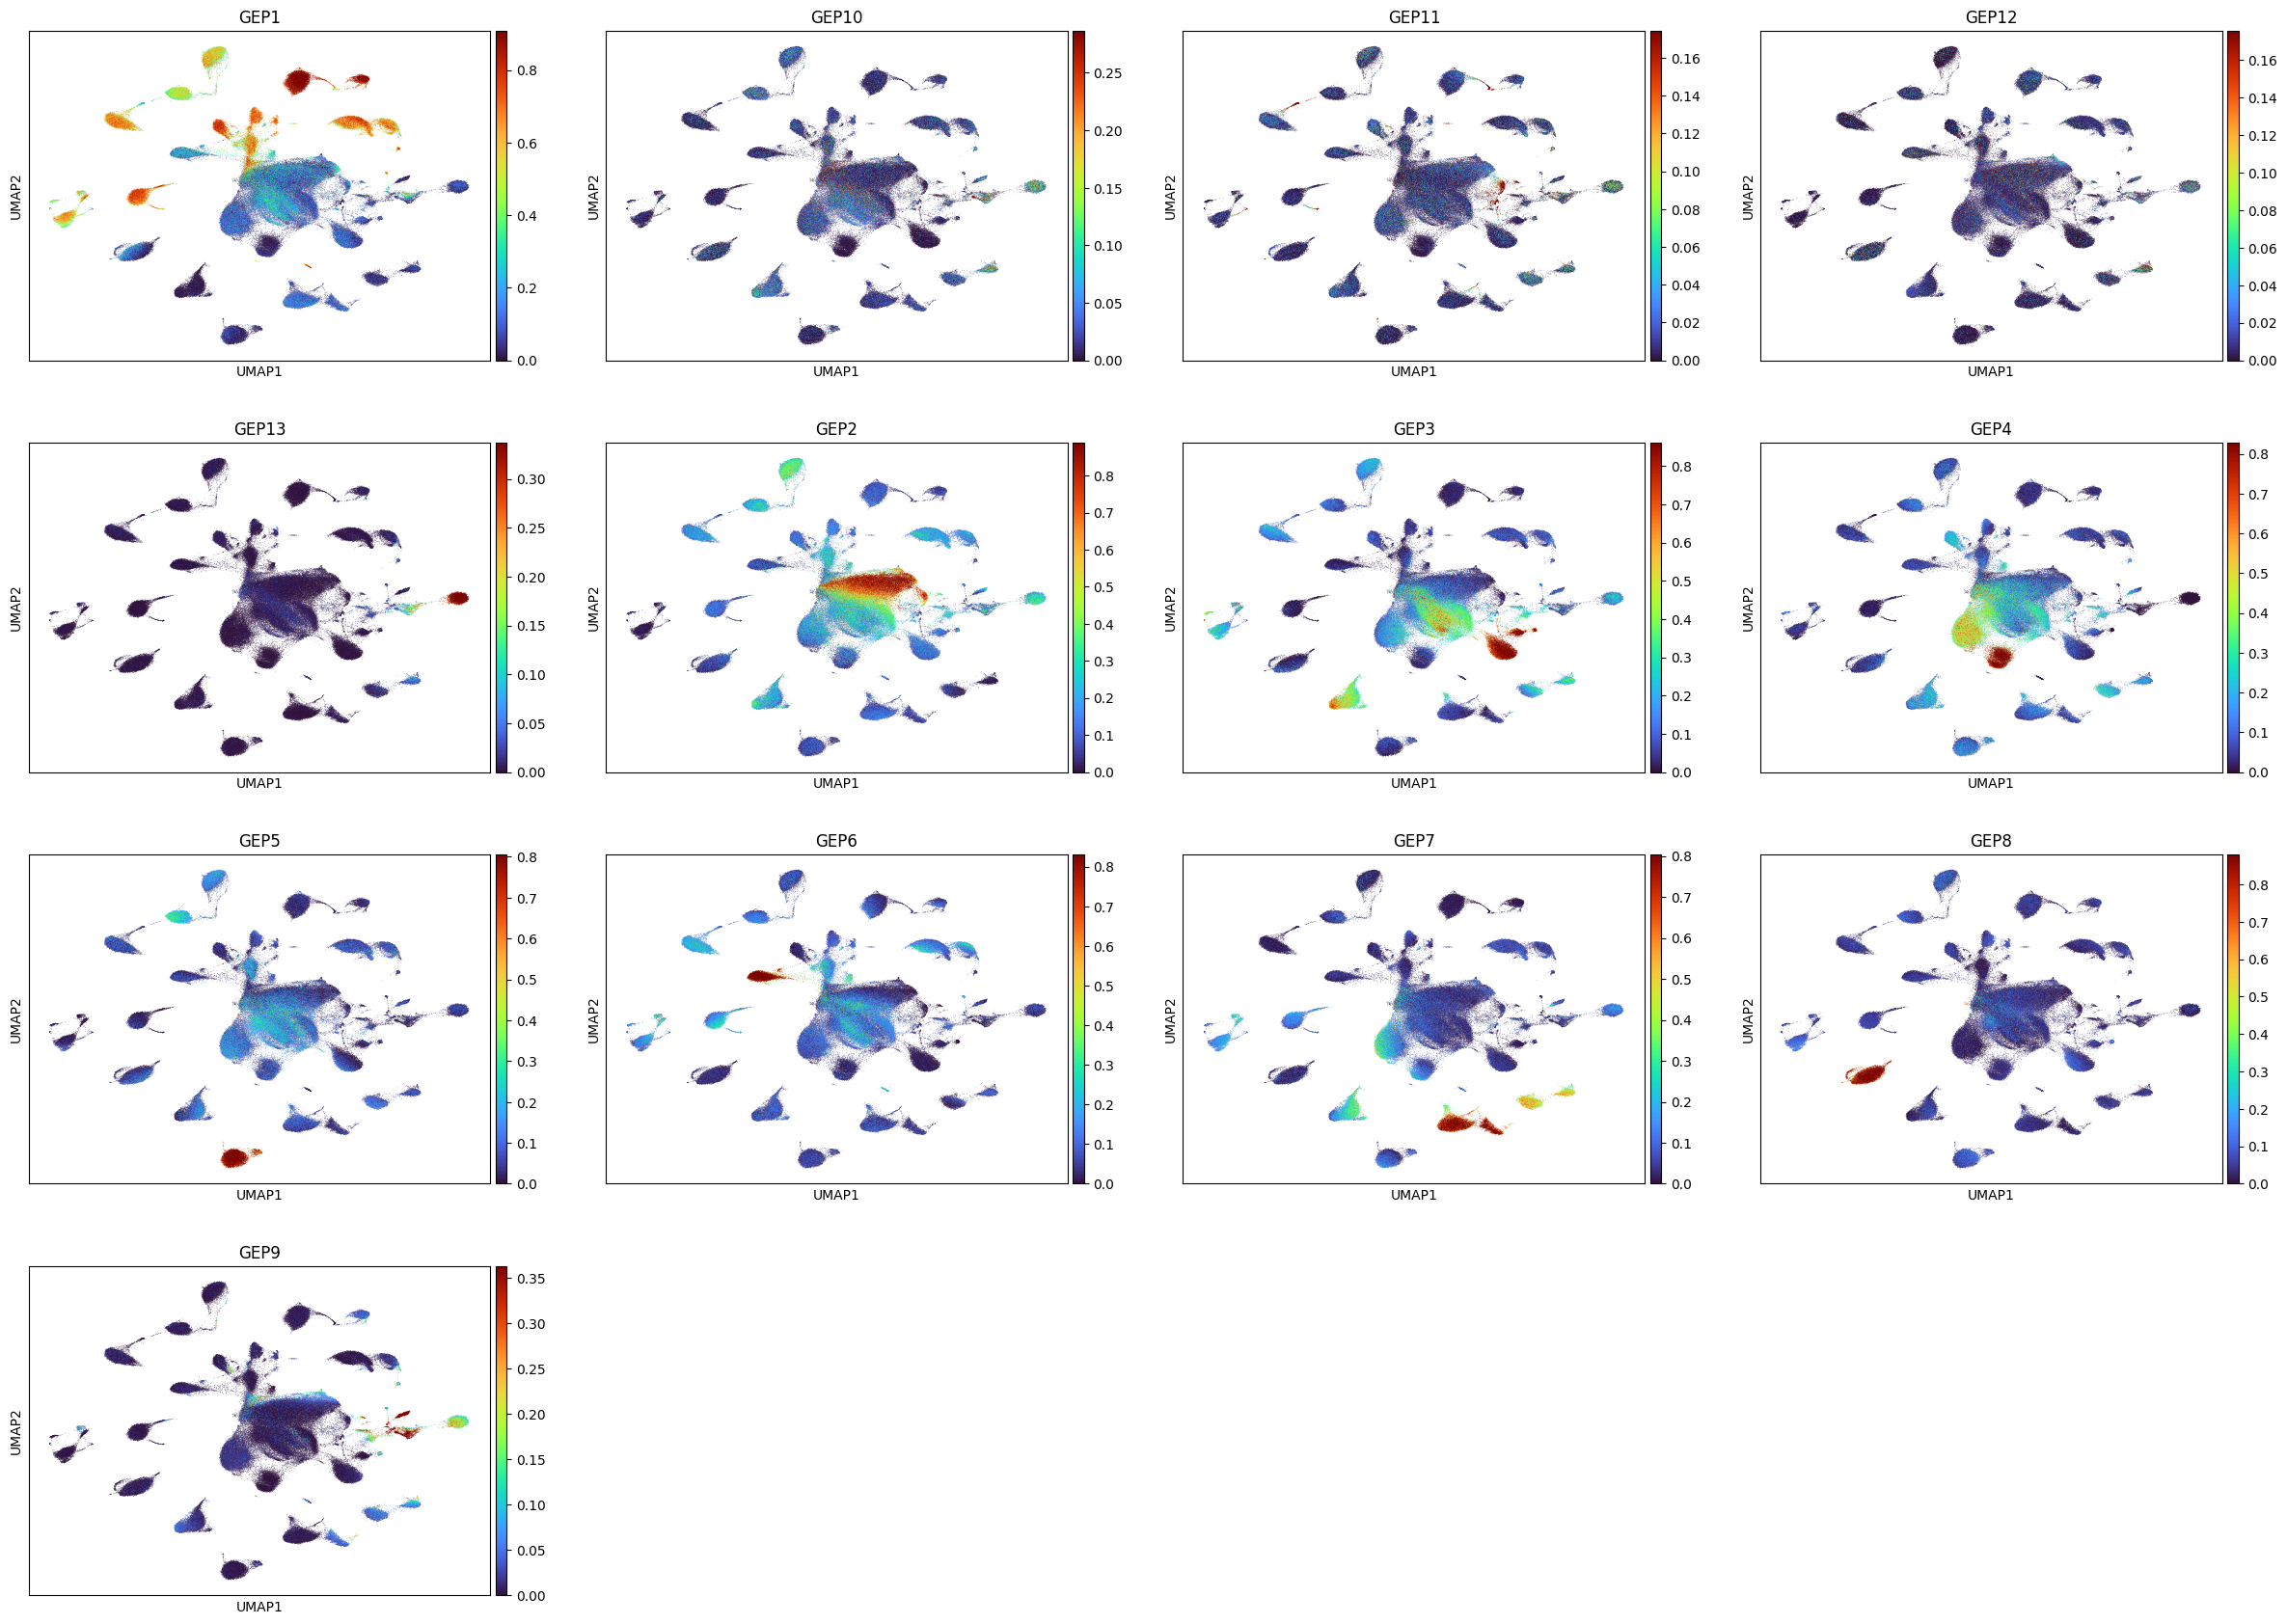

In [10]:
sc.pl.umap(adata, color=sorted(usage.columns), ncols=4, vmin=0, vmax='p99',color_map="turbo")

In [11]:
import math
import scanpy as sc
import matplotlib.pyplot as plt

# --- inputs ---
features = sorted(usage.columns)
ncols = 4
nrows = math.ceil(len(features) / ncols)

# --- make each panel more "square" by controlling inches per panel ---
panel_size = 3.2  # tune this (e.g., 2.8-4.0)
figsize = (panel_size * ncols, panel_size * nrows)

# Option A (recommended): set scanpy global figure params (works in older versions)
sc.set_figure_params(figsize=figsize)

# (Optional) tighten spacing between panels a bit
hspace = 0.35
wspace = 0.25

# --- plot (no figsize argument here) ---
sc.pl.umap(
    adata,
    color=features,
    ncols=ncols,
    vmin=0,
    vmax="p99",
    color_map="turbo",
    show=False,
    hspace=hspace,
    wspace=wspace,
)

# --- save to PDF ---
out_pdf = "umap_usage_panels.pdf"
plt.savefig(out_pdf, bbox_inches="tight")
plt.close()
print(f"Saved: {out_pdf}")


Saved: umap_usage_panels.pdf


In [12]:
import numpy as np
import pandas as pd

# --- choose the CNMF usage columns of interest ---
use_cols = ["GEP1", "GEP2", "GEP3", "GEP4", "GEP6", "GEP7", "GEP8", "GEP9","GEP11"]
present = [c for c in use_cols if c in adata.obs.columns]
if len(present) == 0:
    raise ValueError("None of the required CNMF columns are present in adata.obs")

# Subset and ensure numeric
U = adata.obs[present].apply(pd.to_numeric, errors="coerce")

# Map column name -> status number
status_map = {"GEP1":1, "GEP2":2,"GEP3":3,"GEP4":4,"GEP6":6,"GEP7":7,"GEP8":8, "GEP9":9,"GEP11":11}

# Row-wise argmax to pick the dominant component
argmax_idx = U.values.argmax(axis=1)  # returns positional index among `present`
chosen_cols = [present[i] if np.isfinite(i) else np.nan for i in argmax_idx]

# Convert chosen column names to status numbers; NaN if all four are NaN
status = []
confidence = []
for i, row in U.iterrows():
    vals = row.values.astype(float)
    if np.all(~np.isfinite(vals)):
        status.append(np.nan)
        confidence.append(np.nan)
        continue
    s = np.nansum(vals)
    m = np.nanmax(vals)
    # chosen column:
    j = np.nanargmax(vals)
    status.append(status_map[present[j]])
    # confidence = max / sum (guard zero/NaN)
    conf = (m / s) if (np.isfinite(m) and np.isfinite(s) and s > 0) else np.nan
    confidence.append(conf)

adata.obs["cnmf_status"] = pd.Series(status, index=U.index).astype("Float64")
adata.obs["cnmf_status_confidence"] = pd.Series(confidence, index=U.index).astype("Float64")

# Optional: mark low-confidence as unclassified (commented out)
# THRESH = 0.4
# mask_low = adata.obs["cnmf_status_confidence"].fillna(0) < THRESH
# adata.obs.loc[mask_low, "cnmf_status"] = pd.NA

# Make a categorical for nicer plotting (keeps numeric labels as strings)
adata.obs["cnmf_status_cat"] = (
    adata.obs["cnmf_status"]
    .astype("Int64")
    .astype(str)
    .replace({"<NA>": "NA"})
    .astype("category")
)

print(
    "Assigned cnmf_status to "
    f"{adata.obs['cnmf_status'].notna().sum()} / {adata.n_obs} cells.\n"
    "Value counts:\n",
    adata.obs["cnmf_status_cat"].value_counts(dropna=False)
)


Assigned cnmf_status to 232291 / 232300 cells.
Value counts:
 cnmf_status_cat
1     74311
2     46538
3     36734
4     29189
7     20757
8     10427
6      9414
9      3843
11     1078
NA        9
Name: count, dtype: int64


/home/miniconda3/envs/cassiopeia/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


<Axes: title={'center': 'cnmf_status_cat'}, xlabel='UMAP1', ylabel='UMAP2'>

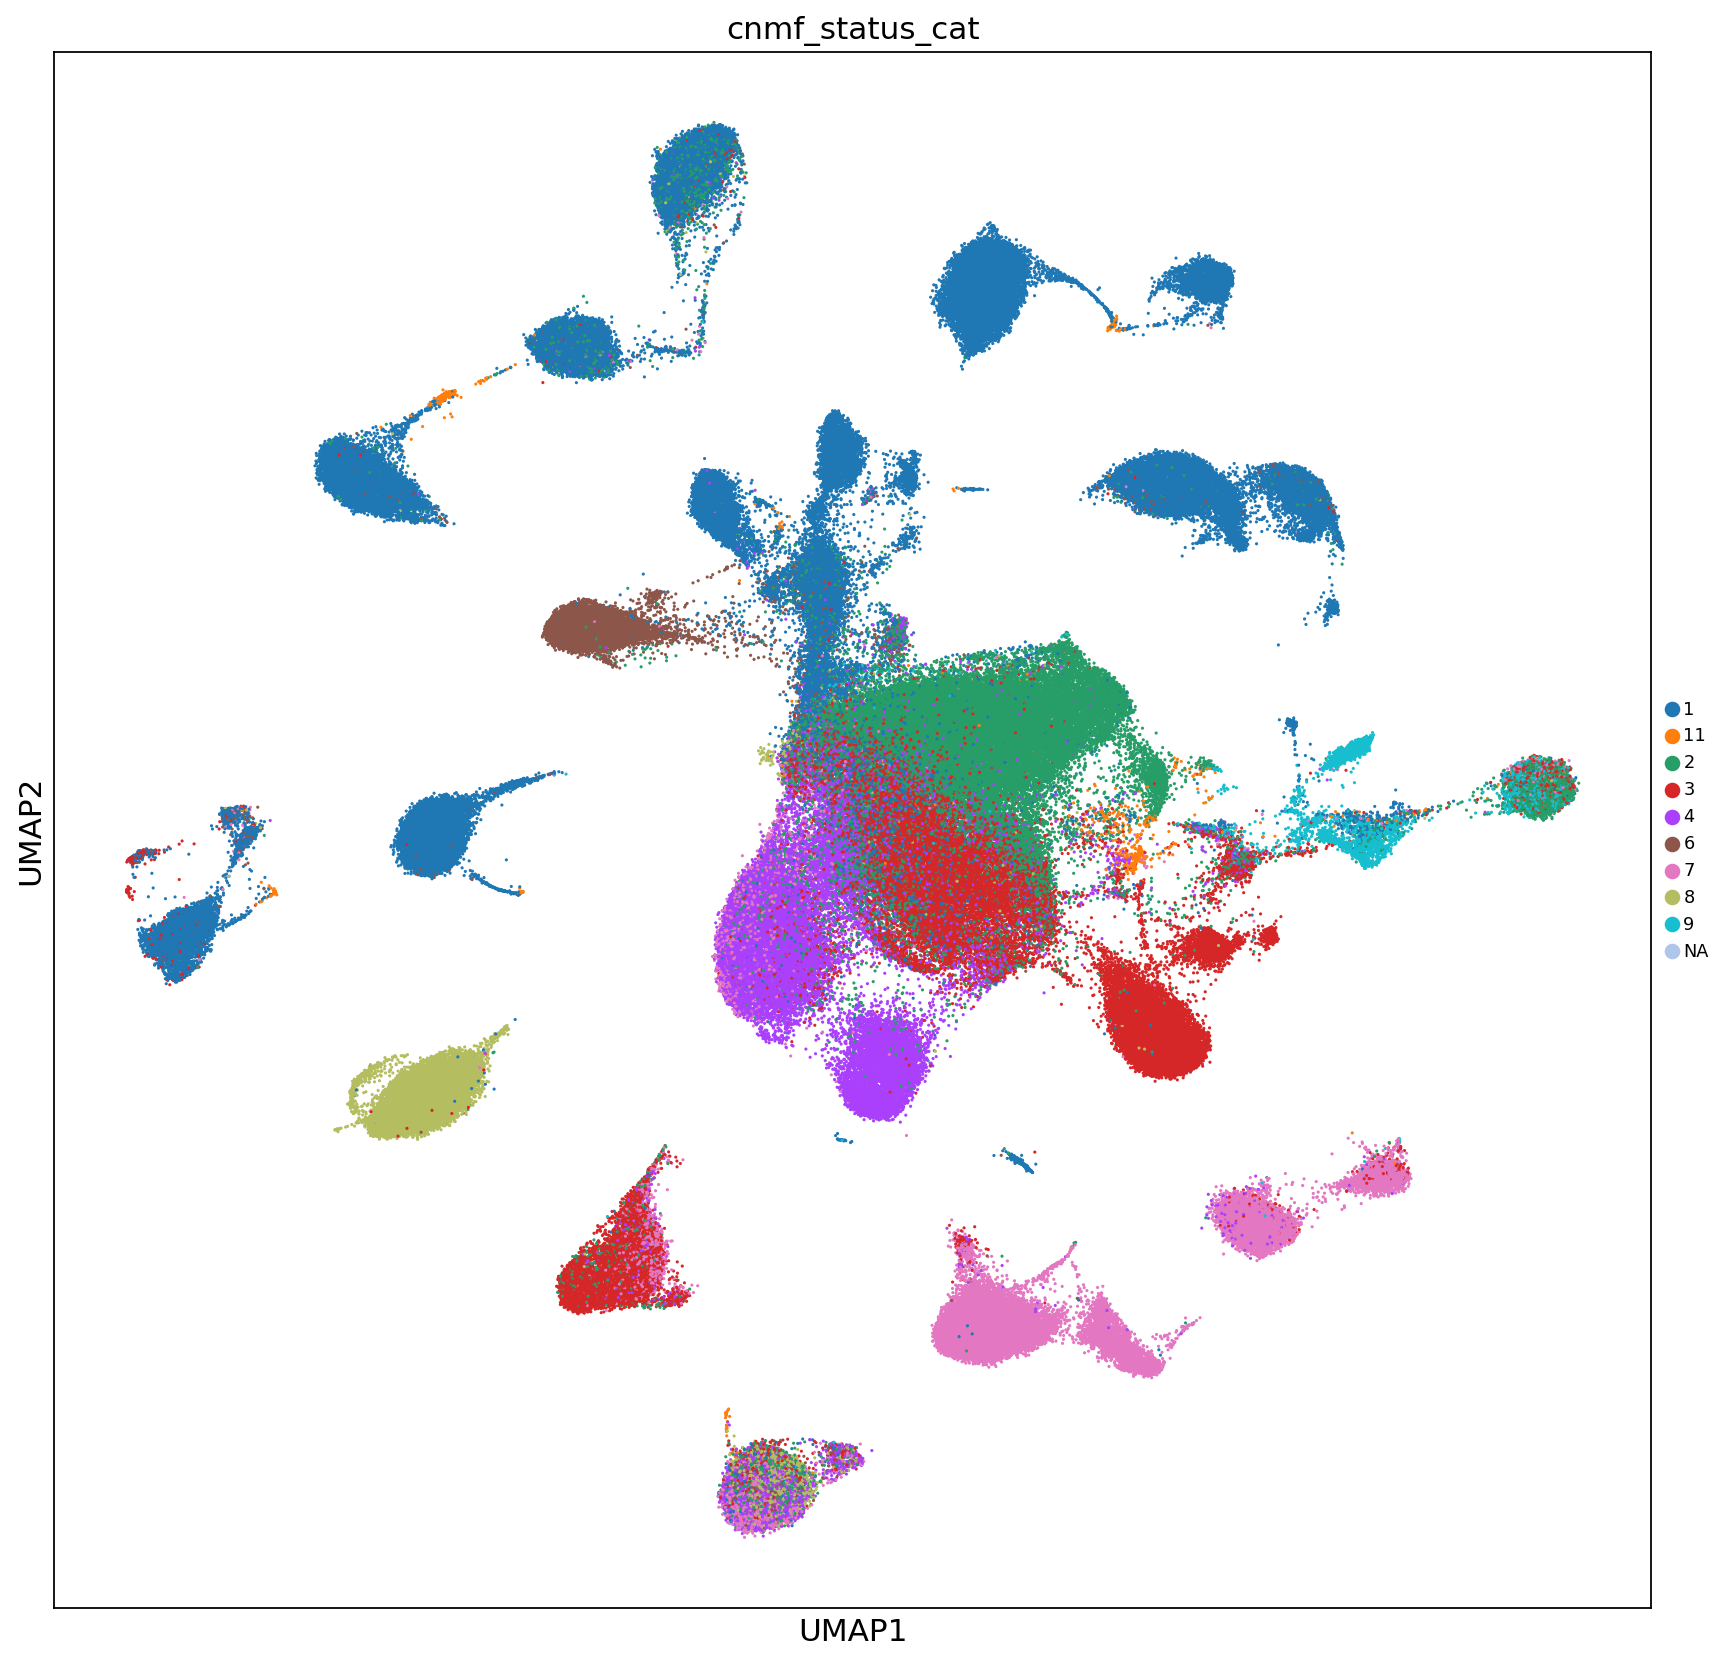

In [13]:

# --- Figure layout (2 panels side by side)
ncols = 2
nrows = 1
figsize = 5
wspace = 0.5

sc.pl.umap(
    adata,
    color=["cnmf_status_cat"],
    show=False,
    legend_loc="right margin",   # move legend outside to save space
    legend_fontsize=8,
    size=8,
    wspace=0.3,
)


## 4. Visualization and figure generation


/home/miniconda3/envs/cassiopeia/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


<Axes: title={'center': 'cnmf_status_cat'}, xlabel='UMAP1', ylabel='UMAP2'>

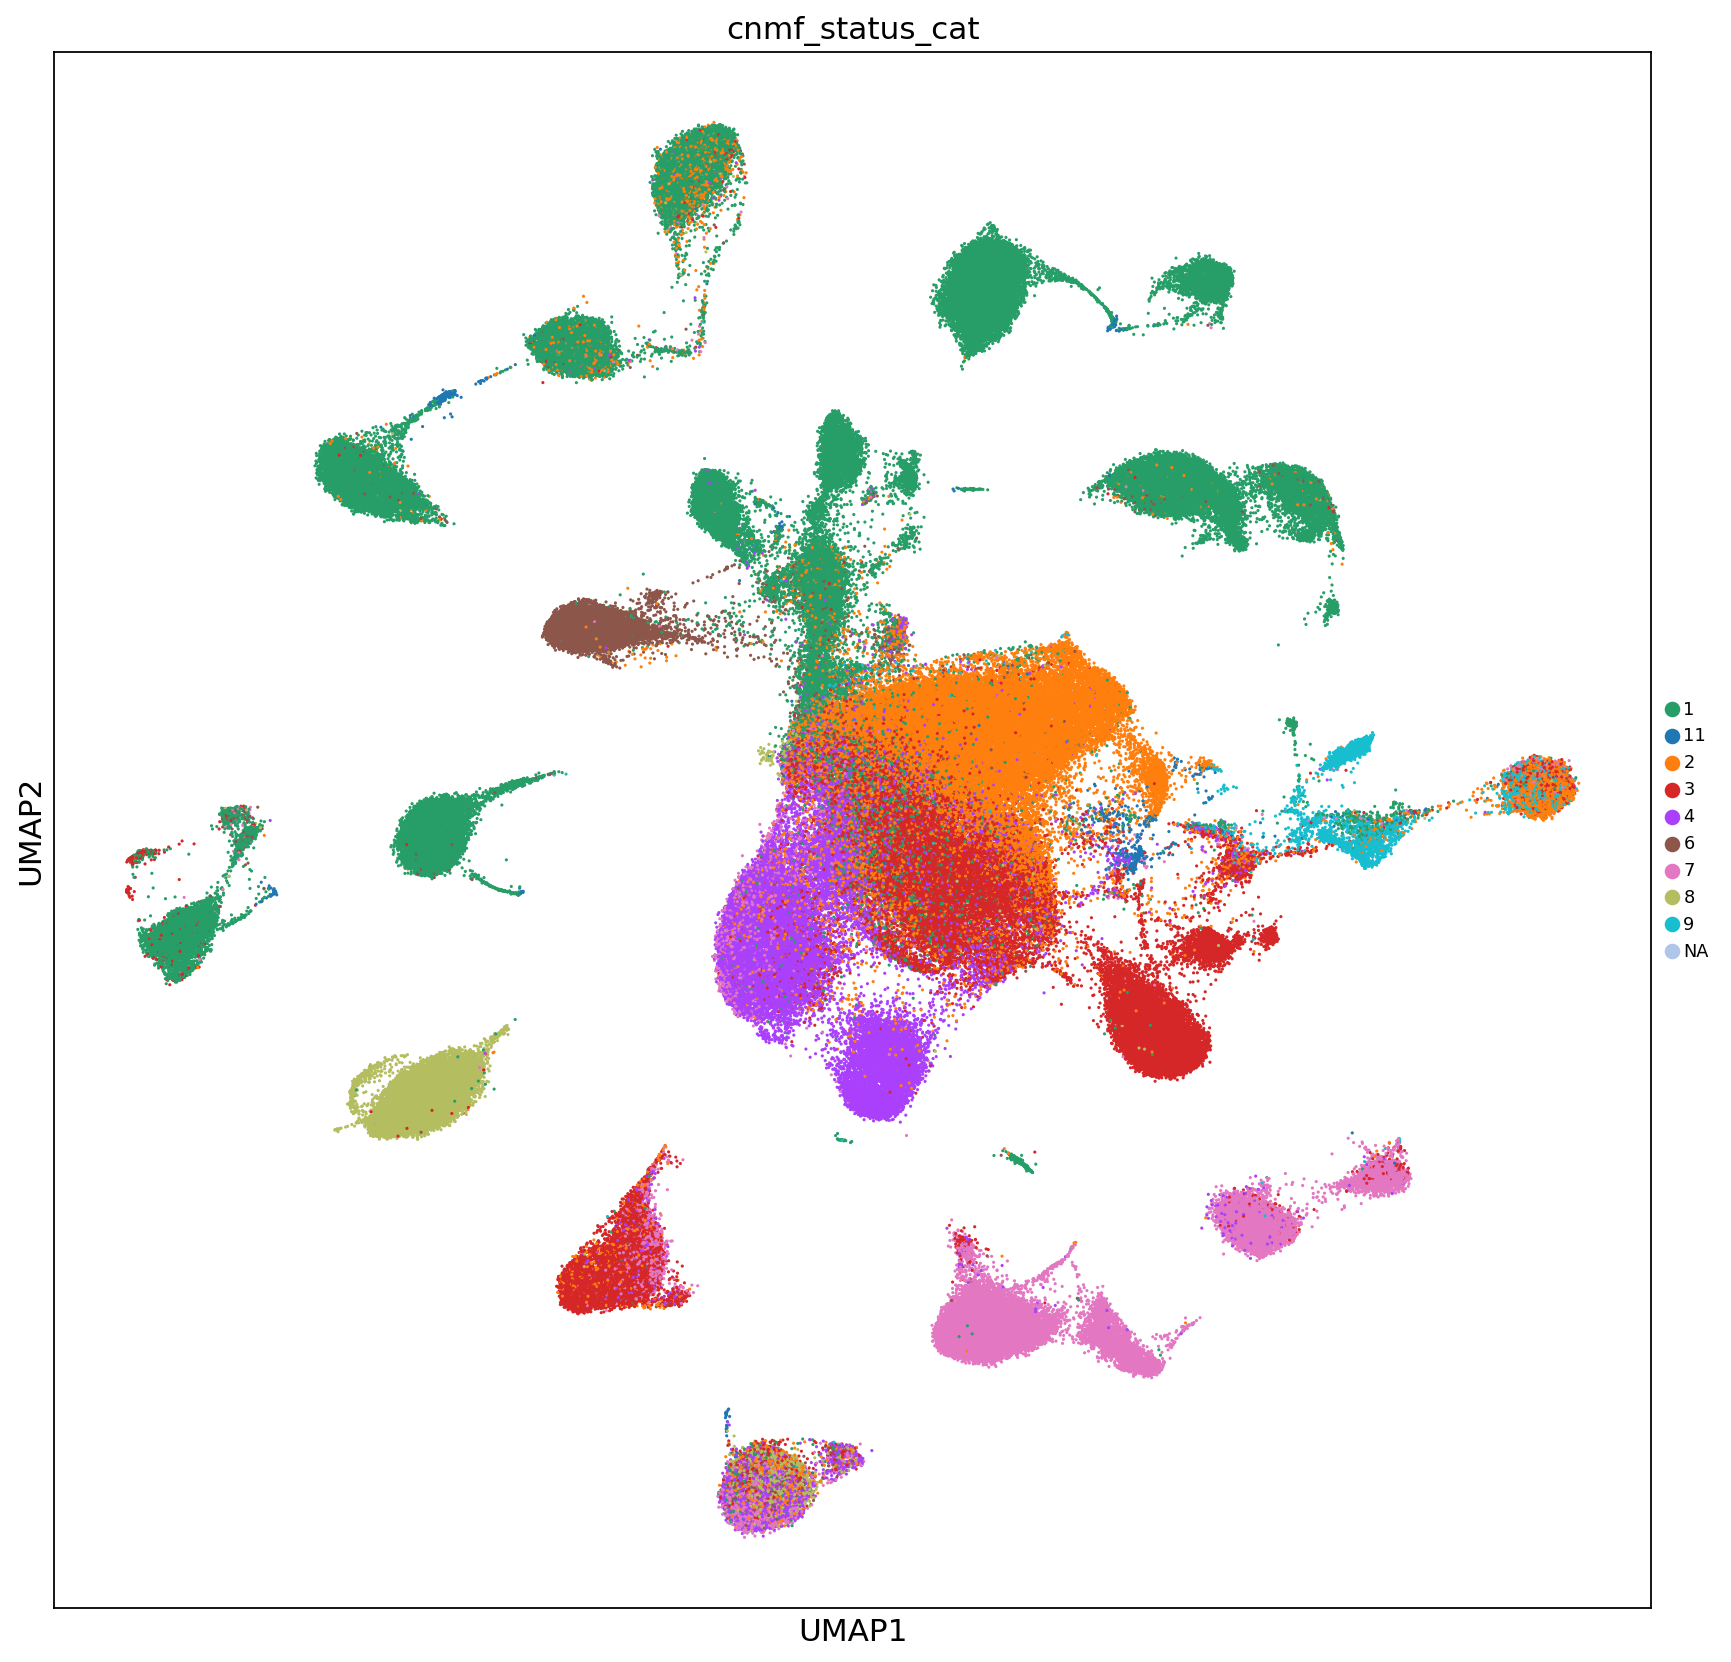

In [14]:
import scanpy as sc

groupby = "cnmf_status_cat"

# Ensure the grouping variable is categorical
adata.obs[groupby] = adata.obs[groupby].astype("category")

# Initialize Scanpy colors if they do not already exist
color_key = f"{groupby}_colors"
if color_key not in adata.uns:
    sc.pl.umap(
        adata,
        color=groupby,
        show=False,
    )

# Category order corresponds directly to the color order
categories = list(adata.obs[groupby].cat.categories)
colors = list(adata.uns[color_key])

# Check that all requested clusters exist
required_clusters = ["1", "2", "11"]
missing = [x for x in required_clusters if x not in categories]

if missing:
    raise ValueError(
        f"Clusters not found in {groupby}: {missing}. "
        f"Available clusters: {categories}"
    )

# Get category positions
idx_1 = categories.index("1")
idx_2 = categories.index("2")
idx_11 = categories.index("11")

# Sequential swaps:
# 1) swap "1" and "2"
colors[idx_1], colors[idx_2] = colors[idx_2], colors[idx_1]

# 2) swap the current colors of "2" and "11"
colors[idx_2], colors[idx_11] = colors[idx_11], colors[idx_2]

# Save the revised color mapping
adata.uns[color_key] = colors


# --- Figure layout
ncols = 2
nrows = 1
figsize = 5
wspace = 0.5

sc.pl.umap(
    adata,
    color=[groupby],
    show=False,
    legend_loc="right margin",
    legend_fontsize=8,
    size=8,
    wspace=0.3,
)

/home/miniconda3/envs/cassiopeia/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


<Axes: title={'center': 'cnmf_status_cat'}, xlabel='UMAP1', ylabel='UMAP2'>

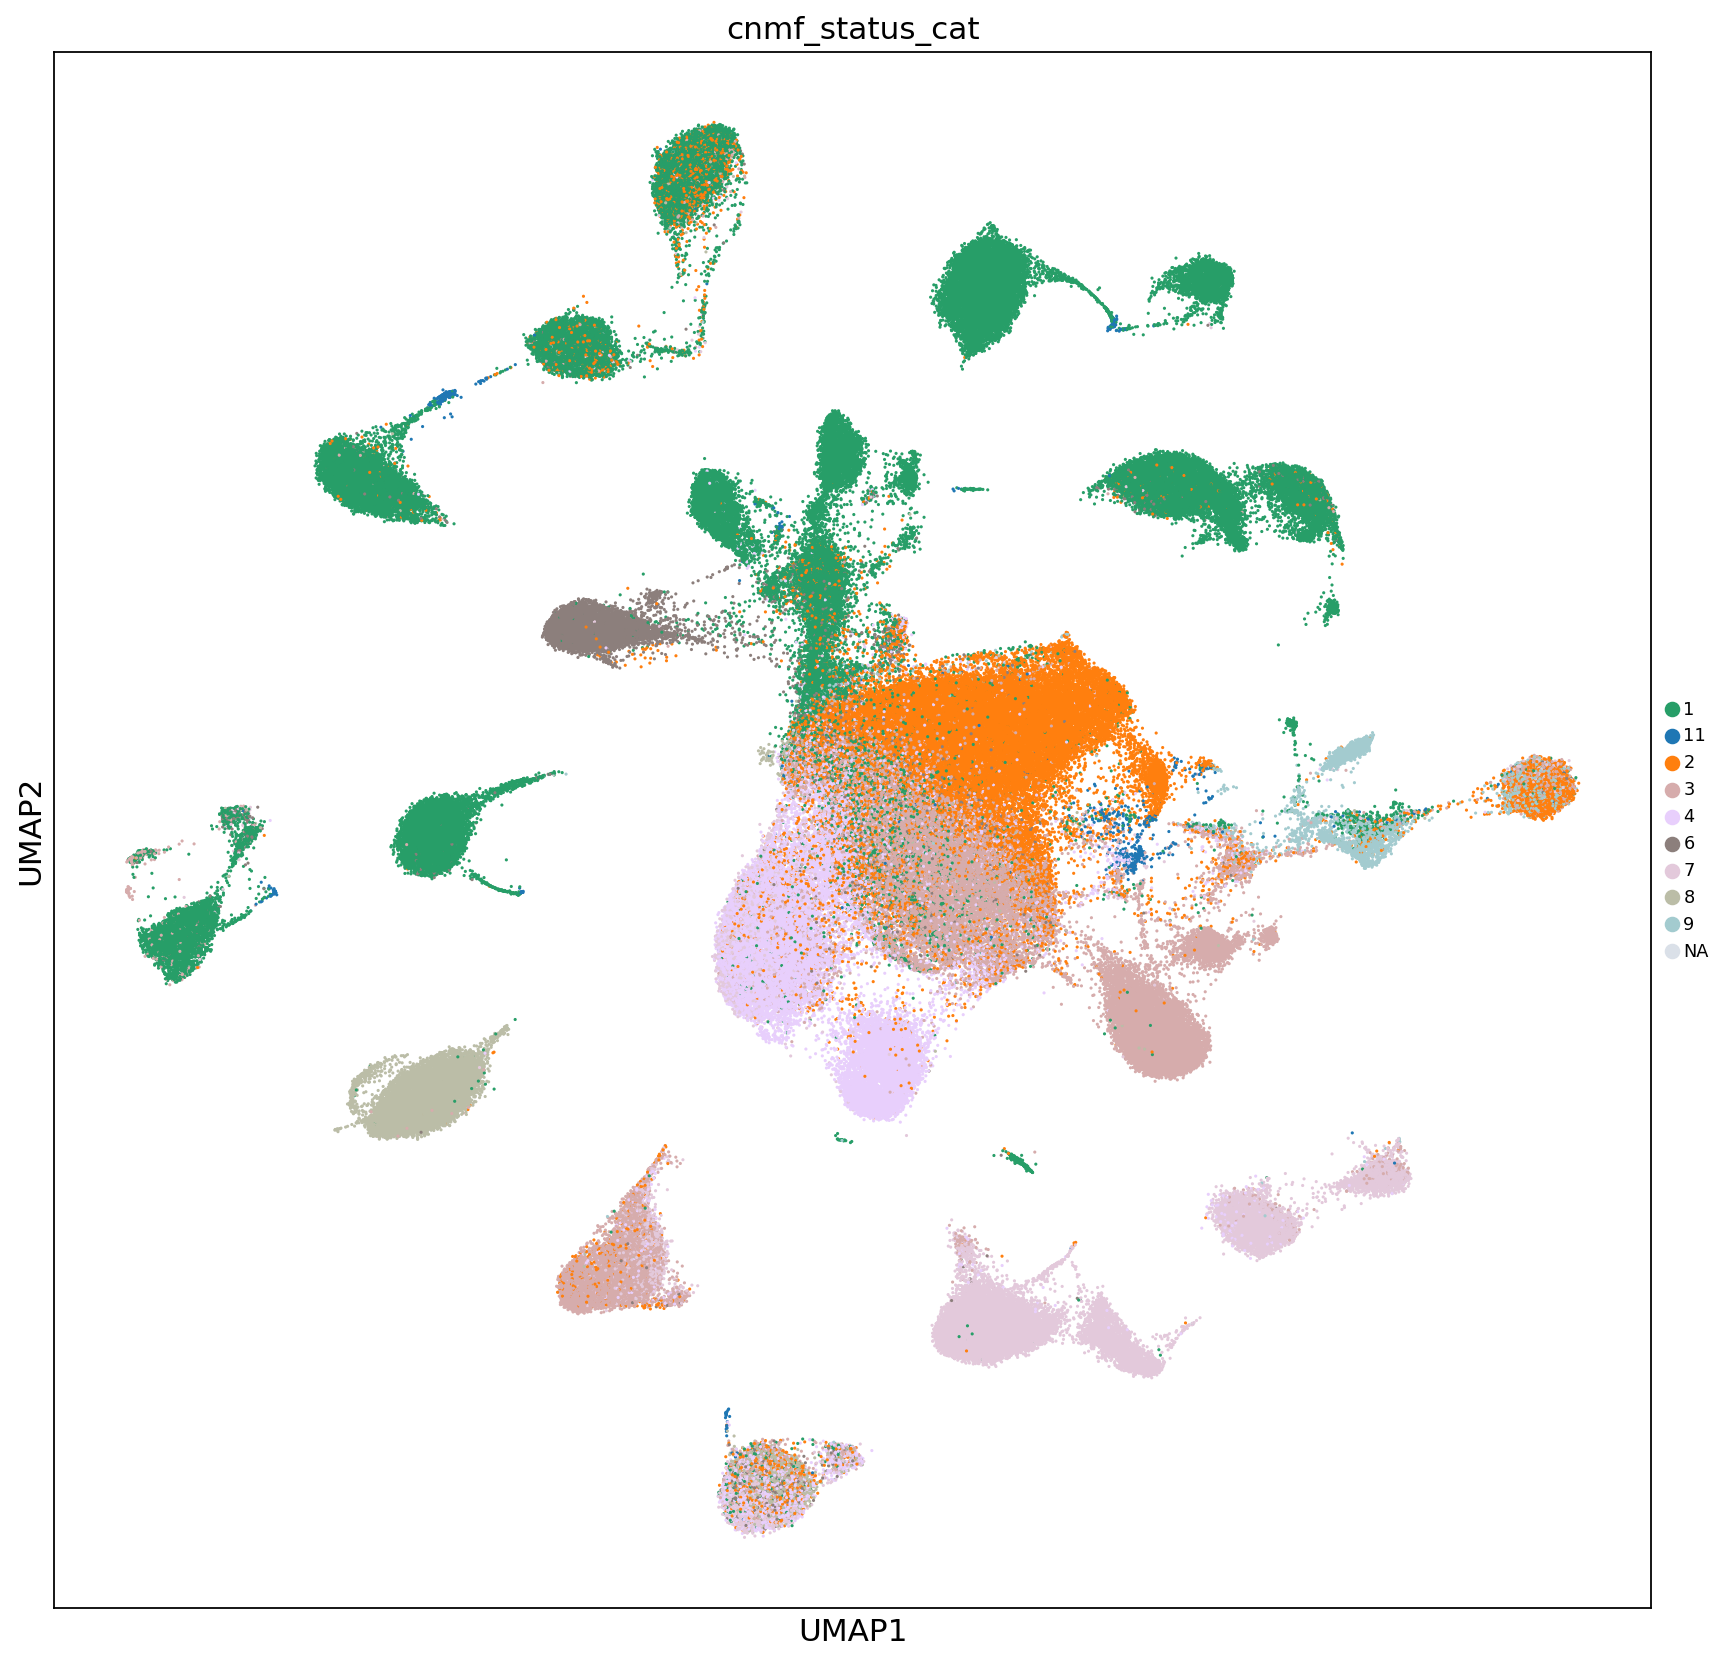

In [18]:
import colorsys
import matplotlib.colors as mcolors
import scanpy as sc

groupby = "cnmf_status_cat"
color_key = f"{groupby}_colors"

# Lower saturation for all clusters except 1, 2, and 11
keep_saturated = {"1", "2", "11"}
saturation_factor = 0.6

def reduce_saturation(color, factor=0.8):
    r, g, b = mcolors.to_rgb(color)
    h, s, v = colorsys.rgb_to_hsv(r, g, b)
    r_new, g_new, b_new = colorsys.hsv_to_rgb(h, s * factor, v)
    return mcolors.to_hex((r_new, g_new, b_new))

colors = [
    color if cluster in keep_saturated
    else reduce_saturation(color, saturation_factor)
    for cluster, color in zip(categories, colors)
]

adata.uns[color_key] = colors


sc.pl.umap(
    adata,
    color=[groupby],
    show=False,
    legend_loc="right margin",
    legend_fontsize=8,
    size=8,
    wspace=0.3,
)

In [16]:
import matplotlib.pyplot as plt

fig = sc.pl.umap(
    adata,
    color=[groupby],
    show=False,
    return_fig=True,
    legend_loc="right margin",
    legend_fontsize=8,
    size=8,
    wspace=0.3,
)

fig.savefig(
    "cnmf_status_cat_umap.pdf",
    format="pdf",
    bbox_inches="tight",
)

plt.close(fig)

/home/miniconda3/envs/cassiopeia/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


## 5. Ensure categorical variables


In [20]:
import math
import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc

groupby = "cnmf_status_cat"
splitby = "orig.ident"
color_key = f"{groupby}_colors"

# Ensure categorical variables
adata.obs[groupby] = adata.obs[groupby].astype(str).astype("category")
adata.obs[splitby] = adata.obs[splitby].astype(str).astype("category")

# Check that the colors already exist
if color_key not in adata.uns:
    sc.pl.umap(
        adata,
        color=groupby,
        show=False,
    )

# Global category-to-color mapping
categories = list(adata.obs[groupby].cat.categories)
colors = list(adata.uns[color_key])

if len(categories) != len(colors):
    raise ValueError(
        f"Number of categories ({len(categories)}) does not match "
        f"number of colors ({len(colors)})."
    )

palette_dict = dict(zip(categories, colors))

# Sample names
sample_ids = list(adata.obs[splitby].cat.categories)

# Figure layout
ncols = 3
nrows = math.ceil(len(sample_ids) / ncols)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(5 * ncols, 4.5 * nrows),
)

axes = np.atleast_1d(axes).ravel()

# Use the same UMAP limits in every panel
umap_coords = adata.obsm["X_umap"]

x_min, x_max = umap_coords[:, 0].min(), umap_coords[:, 0].max()
y_min, y_max = umap_coords[:, 1].min(), umap_coords[:, 1].max()

x_padding = 0.03 * (x_max - x_min)
y_padding = 0.03 * (y_max - y_min)

for i, sample_id in enumerate(sample_ids):

    ax = axes[i]

    # Subset to one sample
    sample_mask = adata.obs[splitby].astype(str).eq(str(sample_id))
    adata_sample = adata[sample_mask].copy()

    # Ensure identical category definitions
    adata_sample.obs[groupby] = (
        adata_sample.obs[groupby]
        .astype(str)
        .astype(
            "category"
        )
        .cat.set_categories(categories)
    )

    # Restore the same color assignment
    adata_sample.uns[color_key] = colors

    # Show legend only on the final populated panel
    legend_loc = (
        "right margin"
        if i == len(sample_ids) - 1
        else None
    )

    sc.pl.umap(
        adata_sample,
        color=groupby,
        palette=palette_dict,
        ax=ax,
        show=False,
        size=8,
        title=str(sample_id),
        legend_loc=legend_loc,
        legend_fontsize=8,
        frameon=False,
    )

    # Apply identical axis limits
    ax.set_xlim(x_min - x_padding, x_max + x_padding)
    ax.set_ylim(y_min - y_padding, y_max + y_padding)

    # Optional sample cell count
    ax.set_title(
        f"{sample_id}\n(n={adata_sample.n_obs:,})",
        fontsize=11,
    )

# Remove unused axes
for j in range(len(sample_ids), len(axes)):
    axes[j].axis("off")

plt.subplots_adjust(
    wspace=0.35,
    hspace=0.35,
)

output_file = "cnmf_status_cat_umap_split_by_orig_ident.pdf"

fig.savefig(
    output_file,
    format="pdf",
    bbox_inches="tight",
)

plt.close(fig)

print(f"Saved to: {output_file}")

/home/miniconda3/envs/cassiopeia/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/miniconda3/envs/cassiopeia/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/miniconda3/envs/cassiopeia/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/miniconda3/envs/cassiopeia/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/miniconda3/envs/cassiopeia/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided 

Saved to: cnmf_status_cat_umap_split_by_orig_ident.pdf


In [14]:
usage_norm = adata.obs[use_cols]

In [15]:
usage_norm.to_csv("plasma_cnmf_3_usage_norm_withoutIG_k=13_allplasmacell.csv", index=True)

In [16]:
import pandas as pd

# pick the source AnnData and the column you want to transfer
src = adata
col = "cnmf_status_cat"

# export with cell barcodes (obs_names) as the key
out_csv = "cnmf_status_cat_annotation.csv"
src.obs[[col]].to_csv(out_csv, index=True)  # index=True keeps barcodes

print("Saved:", out_csv, "rows:", src.n_obs)


Saved: cnmf_status_cat_annotation.csv rows: 232300


/home/miniconda3/envs/cassiopeia/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


<Axes: title={'center': 'orig_ident_N_status'}, xlabel='UMAP1', ylabel='UMAP2'>

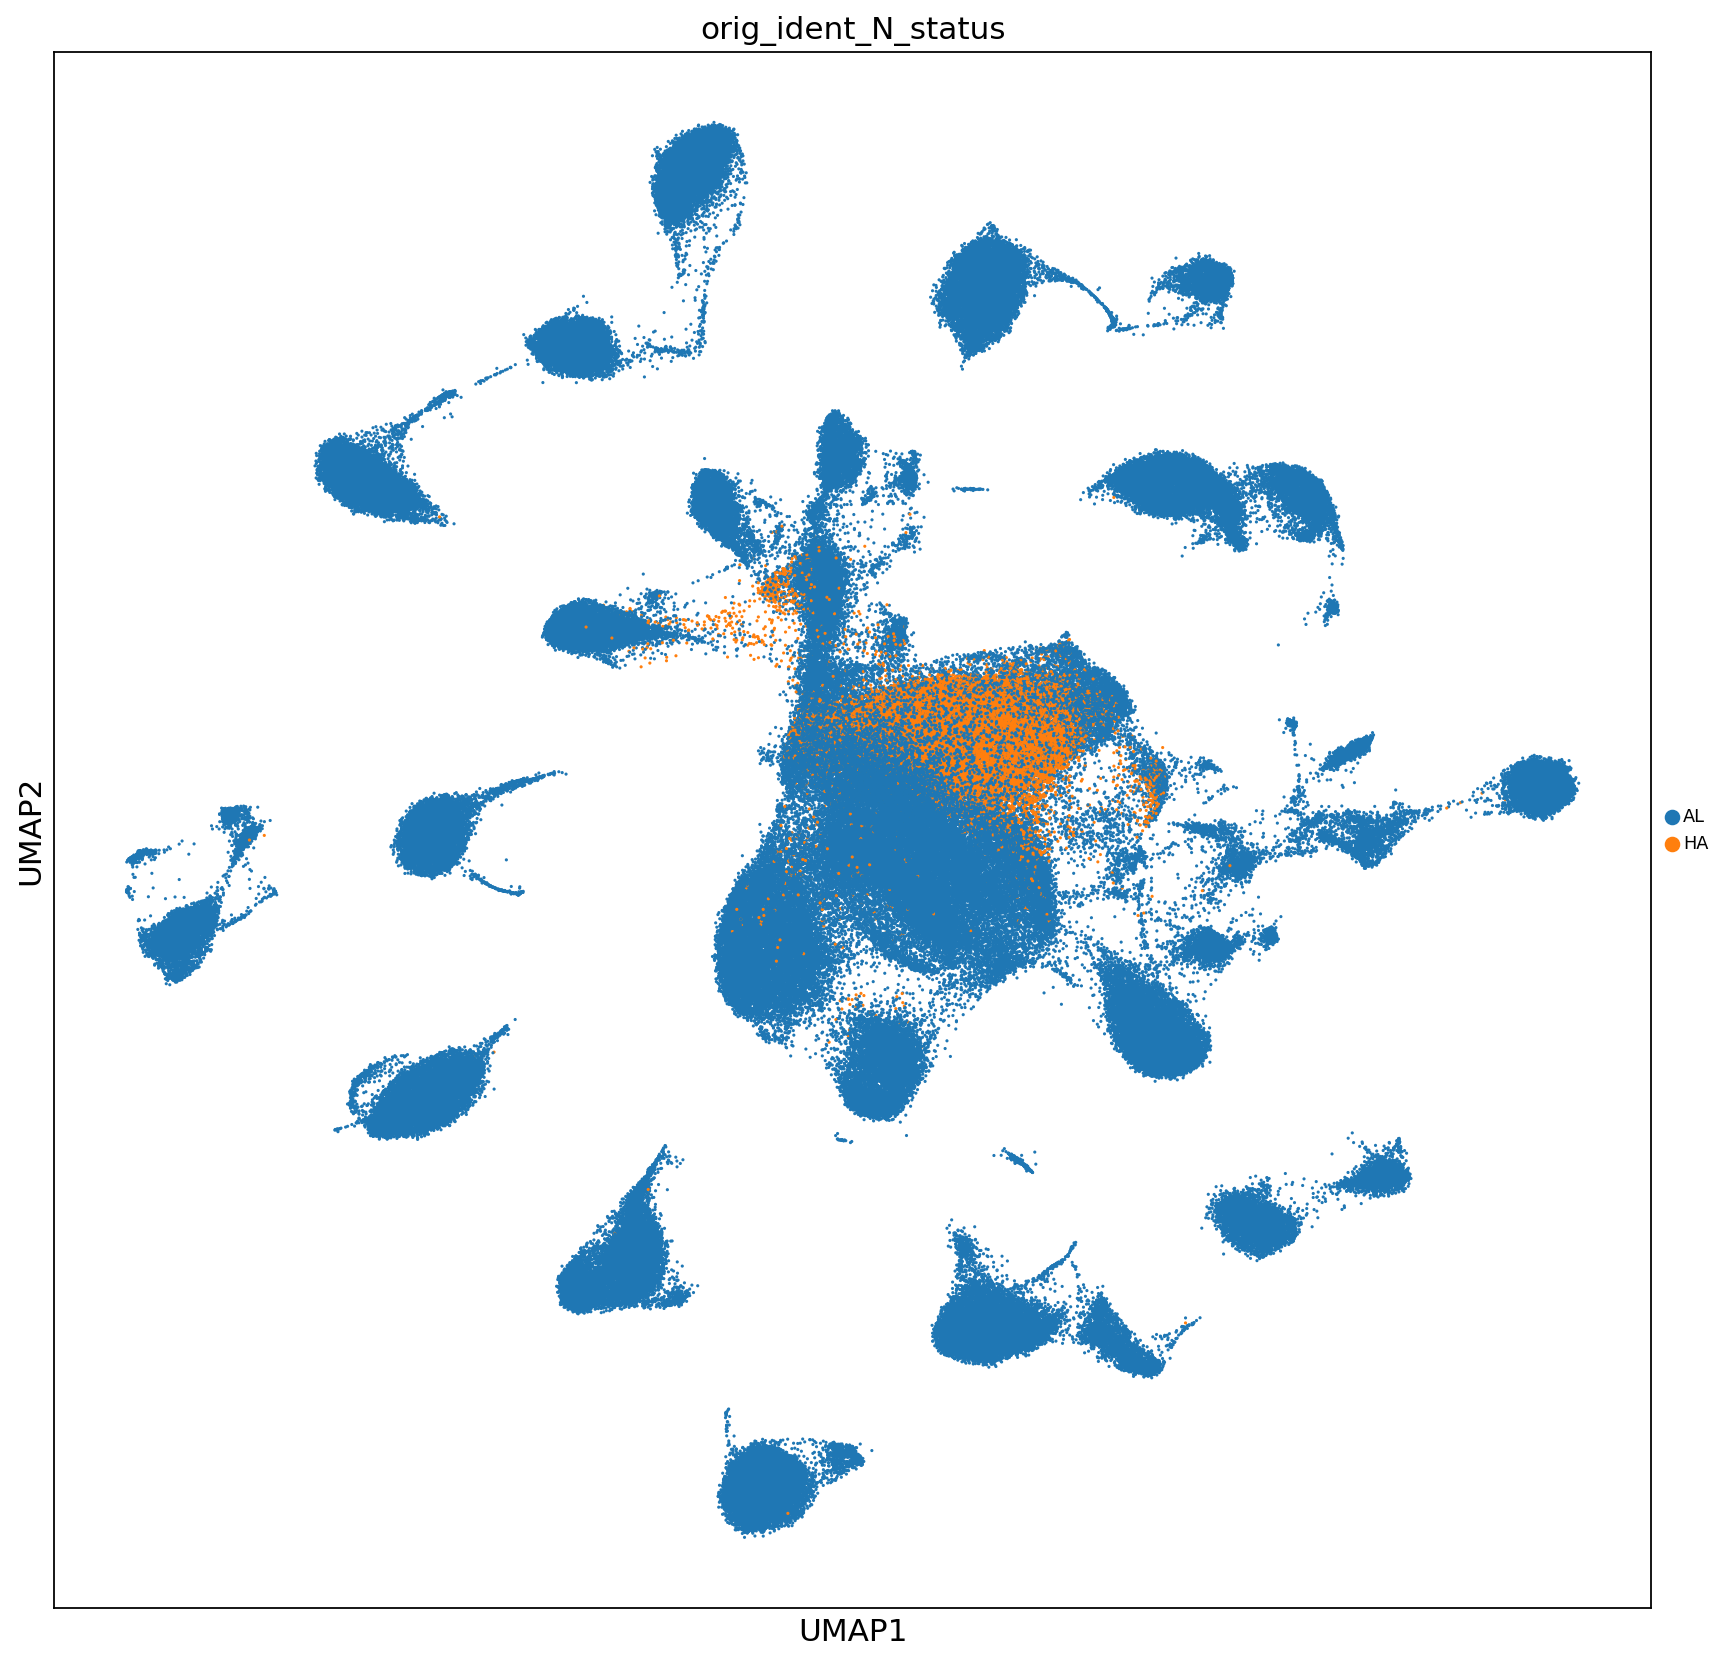

In [17]:
import pandas as pd
import numpy as np

# Classify by whether orig.ident starts with "N"
adata.obs["orig_ident_N_status"] = np.where(
    adata.obs["orig.ident"].astype(str).str.startswith("N"),
    "HA",   # Yes, starts with N
    "AL"    # No, does not start with N
)

# Force category order so AL = default blue, HA = default orange
adata.obs["orig_ident_N_status"] = pd.Categorical(
    adata.obs["orig_ident_N_status"],
    categories=["AL", "HA"],
    ordered=True
)

sc.pl.umap(
    adata,
    color=["orig_ident_N_status"],
    palette=["#1f77b4", "#ff7f0e"],  # default matplotlib blue/orange
    show=False,
    legend_loc="right margin",
    legend_fontsize=8,
    size=8,
    wspace=0.3,
)

## 6. Gene-expression program analysis


Components aligned by index, k=9:
  Usage_1<->GEP1, Usage_2<->GEP2, Usage_3<->GEP3, Usage_4<->GEP4, Usage_6<->GEP6, Usage_7<->GEP7, Usage_8<->GEP8, Usage_9<->GEP9, Usage_11<->GEP11
Exact barcode match: 181,826/181,826
Final orig.ident recovered: 181,826/181,826
gt cells: 181,826
gt cells missing orig.ident: 0
Exact barcode match: 232,300/232,300
Final orig.ident recovered: 232,300/232,300
pred cells: 232,300
pred cells missing orig.ident: 0
gt_with_plasma cells: 181,826
pred_withplasma cells: 202,788
pred_withoutplasma cells: 29,512
pred_all cells: 232,300

Group-level component profiles:


,Comp_1,Comp_2,Comp_3,Comp_4,Comp_6,Comp_7,Comp_8,Comp_9,Comp_11
group,,,,,,,,,
gt_with_plasma,0.243036,0.163952,0.130928,0.109225,0.080026,0.086257,0.048740,0.012562,0.010123
pred_withplasma,0.224911,0.185714,0.131015,0.114476,0.079692,0.078786,0.056525,0.009677,0.009538
pred_withoutplasma,0.228532,0.122310,0.139323,0.060742,0.055822,0.129970,0.029350,0.070081,0.011847
pred_all,0.225371,0.177659,0.132071,0.107649,0.076659,0.085289,0.053072,0.017351,0.009831



Sample-level Spearman correlation:


group,gt_with_plasma,pred_withplasma,pred_withoutplasma,pred_all
group,,,,
gt_with_plasma,1.000000,0.983333,0.800000,1.000000
pred_withplasma,0.983333,1.000000,0.733333,0.983333
pred_withoutplasma,0.800000,0.733333,1.000000,0.800000
pred_all,1.000000,0.983333,0.800000,1.000000


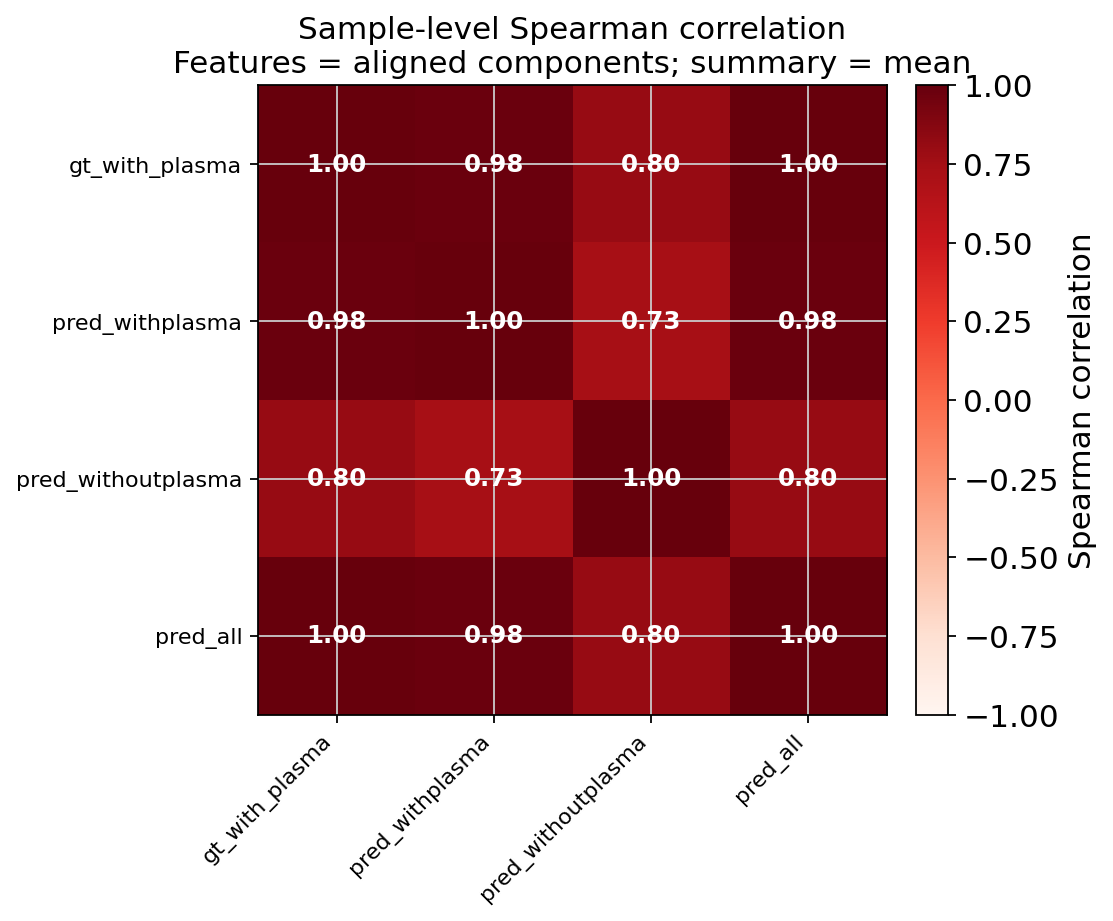

Wrote: sample_level_gt_pred_heatmap.png
Wrote: sample_level_gt_pred_heatmap.pdf
Wrote: sample_level_gt_pred_profiles.csv
Wrote: sample_level_gt_pred_spearman_corr.csv


In [21]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------
# 0) Inputs
# ---------------------------
gt_path   = "plasma_cnmf_3_usage_norm_withoutIG_k=13.csv"
pred_path = "plasma_cnmf_3_usage_norm_withoutIG_k=13_allplasmacell.csv"

ORIG_IDENT_COL = "orig.ident"

GROUP_SUMMARY_METHOD = "mean"   # "mean" or "median"

out_png = "sample_level_gt_pred_heatmap.png"
out_pdf = "sample_level_gt_pred_heatmap.pdf"
out_profile_csv = "sample_level_gt_pred_profiles.csv"
out_corr_csv = "sample_level_gt_pred_spearman_corr.csv"

# ---------------------------
# 1) Load
# ---------------------------
gt = pd.read_csv(gt_path)
pr = pd.read_csv(pred_path)

gt_barcode_col = gt.columns[0]
pr_barcode_col = pr.columns[0]

usage_cols = [c for c in gt.columns if re.fullmatch(r"Usage_\d+", str(c))]
gep_cols   = [c for c in pr.columns if re.fullmatch(r"GEP_?\d+", str(c))]

if not usage_cols:
    raise ValueError("No columns like 'Usage_1' found in gt file.")
if not gep_cols:
    raise ValueError("No columns like 'GEP1' or 'GEP_1' found in pred file.")

def trailing_int(x):
    m = re.search(r"(\d+)$", str(x))
    return int(m.group(1)) if m else None

# ---------------------------
# 2) Align components by suffix
# ---------------------------
usage_num_to_col = {
    trailing_int(c): c
    for c in usage_cols
    if trailing_int(c) is not None
}

gep_num_to_col = {
    trailing_int(c): c
    for c in gep_cols
    if trailing_int(c) is not None
}

common_nums = sorted(set(usage_num_to_col).intersection(set(gep_num_to_col)))

if not common_nums:
    raise ValueError("No overlapping component indices between Usage_* and GEP* columns.")

usage_cols_aligned = [usage_num_to_col[i] for i in common_nums]
gep_cols_aligned   = [gep_num_to_col[i] for i in common_nums]

shared_feature_names = [f"Comp_{i}" for i in common_nums]

print(f"Components aligned by index, k={len(common_nums)}:")
print("  " + ", ".join([
    f"{u}<->{g}"
    for u, g in zip(usage_cols_aligned, gep_cols_aligned)
]))

# ---------------------------
# 3) Get orig.ident metadata from adata
# ---------------------------
if "adata" not in globals():
    raise ValueError(
        "adata is not loaded. Please load your AnnData object first, e.g.:\n"
        "import scanpy as sc\n"
        "adata = sc.read_h5ad('your_file.h5ad')"
    )

if ORIG_IDENT_COL not in adata.obs.columns:
    raise ValueError(f"'{ORIG_IDENT_COL}' was not found in adata.obs.")

meta = adata.obs[[ORIG_IDENT_COL]].copy()
meta["barcode"] = meta.index.astype(str)

def barcode_core(x):
    s = str(x)

    for sep in [":", "|"]:
        if sep in s:
            s = s.split(sep)[-1]

    # Only remove sample prefix when it looks like Sample_AAAC...-1
    # Avoid damaging IDs like cellid_000000001-1
    if "_" in s and not s.startswith("cellid_"):
        s = s.split("_")[-1]

    return s

def attach_orig_ident(df):
    """
    Attach orig.ident from adata.obs to a dataframe with column 'barcode'.
    First uses exact barcode matching.
    Then fills remaining missing values using unique barcode-core matching.
    """
    df = df.copy()
    df["barcode"] = df["barcode"].astype(str)

    out = df.merge(meta, on="barcode", how="left")

    n_exact = out[ORIG_IDENT_COL].notna().sum()
    print(f"Exact barcode match: {n_exact:,}/{out.shape[0]:,}")

    # Fallback only for still-missing rows
    if out[ORIG_IDENT_COL].isna().any():
        meta2 = meta.copy()
        meta2["barcode_core"] = meta2["barcode"].map(barcode_core)

        # Keep only uniquely mappable barcode cores
        duplicated_core = meta2["barcode_core"].duplicated(keep=False)
        meta2_unique = meta2.loc[
            ~duplicated_core,
            ["barcode_core", ORIG_IDENT_COL]
        ].copy()

        missing_mask = out[ORIG_IDENT_COL].isna()

        fallback = out.loc[missing_mask, ["barcode"]].copy()
        fallback["barcode_core"] = fallback["barcode"].map(barcode_core)

        fallback = fallback.merge(
            meta2_unique,
            on="barcode_core",
            how="left",
            suffixes=("", "_fallback")
        )

        out.loc[missing_mask, ORIG_IDENT_COL] = fallback[ORIG_IDENT_COL].values

    n_final = out[ORIG_IDENT_COL].notna().sum()
    print(f"Final orig.ident recovered: {n_final:,}/{out.shape[0]:,}")

    return out

# ---------------------------
# 4) Build gt table independently
# ---------------------------
gt_tbl = (
    gt[[gt_barcode_col] + usage_cols_aligned]
    .rename(columns={gt_barcode_col: "barcode"})
    .copy()
)

gt_tbl = attach_orig_ident(gt_tbl)

gt_missing = gt_tbl[ORIG_IDENT_COL].isna().sum()
print(f"gt cells: {gt_tbl.shape[0]:,}")
print(f"gt cells missing orig.ident: {gt_missing:,}")

gt_tbl = gt_tbl.loc[gt_tbl[ORIG_IDENT_COL].notna()].copy()

# ---------------------------
# 5) Build pred table independently
# ---------------------------
pred_tbl = (
    pr[[pr_barcode_col] + gep_cols_aligned]
    .rename(columns={pr_barcode_col: "barcode"})
    .copy()
)

pred_tbl = attach_orig_ident(pred_tbl)

pred_missing = pred_tbl[ORIG_IDENT_COL].isna().sum()
print(f"pred cells: {pred_tbl.shape[0]:,}")
print(f"pred cells missing orig.ident: {pred_missing:,}")

pred_tbl = pred_tbl.loc[pred_tbl[ORIG_IDENT_COL].notna()].copy()

# ---------------------------
# 6) Define plasma / non-plasma masks separately
# ---------------------------
gt_plasma_mask = (
    gt_tbl[ORIG_IDENT_COL]
    .astype(str)
    .str.contains("plasma", case=False, na=False)
)

pred_plasma_mask = (
    pred_tbl[ORIG_IDENT_COL]
    .astype(str)
    .str.contains("plasma", case=False, na=False)
)

print(f"gt_with_plasma cells: {gt_plasma_mask.sum():,}")
print(f"pred_withplasma cells: {pred_plasma_mask.sum():,}")
print(f"pred_withoutplasma cells: {(~pred_plasma_mask).sum():,}")
print(f"pred_all cells: {pred_tbl.shape[0]:,}")

# ---------------------------
# 7) Summarize one group into one component vector
# ---------------------------
def summarize_profile(df, cols, output_names, method="mean"):
    if df.shape[0] < 1:
        return pd.Series([np.nan] * len(cols), index=output_names)

    if method == "mean":
        v = df[cols].mean(axis=0).to_numpy()
    elif method == "median":
        v = df[cols].median(axis=0).to_numpy()
    else:
        raise ValueError("method must be 'mean' or 'median'.")

    return pd.Series(v, index=output_names)

# ---------------------------
# 8) Construct the four profiles
# ---------------------------
profiles = pd.DataFrame({
    "gt_with_plasma": summarize_profile(
        gt_tbl.loc[gt_plasma_mask],
        usage_cols_aligned,
        shared_feature_names,
        method=GROUP_SUMMARY_METHOD
    ),

    "pred_withplasma": summarize_profile(
        pred_tbl.loc[pred_plasma_mask],
        gep_cols_aligned,
        shared_feature_names,
        method=GROUP_SUMMARY_METHOD
    ),

    "pred_withoutplasma": summarize_profile(
        pred_tbl.loc[~pred_plasma_mask],
        gep_cols_aligned,
        shared_feature_names,
        method=GROUP_SUMMARY_METHOD
    ),

    "pred_all": summarize_profile(
        pred_tbl,
        gep_cols_aligned,
        shared_feature_names,
        method=GROUP_SUMMARY_METHOD
    )
}).T

profiles.index.name = "group"

print("\nGroup-level component profiles:")
display(profiles)

profiles.to_csv(out_profile_csv)

# ---------------------------
# 9) Correlate the four profiles
# ---------------------------
sample_corr = profiles.T.corr(method="spearman")

print("\nSample-level Spearman correlation:")
display(sample_corr)

sample_corr.to_csv(out_corr_csv)

# ---------------------------
# 10) Heatmap with white text
# ---------------------------
fig, ax = plt.subplots(figsize=(7, 6))

im = ax.imshow(
    sample_corr.values,
    cmap="Reds",
    vmin=-1,
    vmax=1,
    interpolation="nearest"
)

ax.set_xticks(range(sample_corr.shape[1]))
ax.set_xticklabels(
    sample_corr.columns,
    rotation=45,
    ha="right",
    fontsize=10
)

ax.set_yticks(range(sample_corr.shape[0]))
ax.set_yticklabels(
    sample_corr.index,
    fontsize=10
)

ax.set_title(
    f"Sample-level Spearman correlation\n"
    f"Features = aligned components; summary = {GROUP_SUMMARY_METHOD}"
)

# white text labels
for i in range(sample_corr.shape[0]):
    for j in range(sample_corr.shape[1]):
        val = sample_corr.iloc[i, j]
        if np.isfinite(val):
            ax.text(
                j,
                i,
                f"{val:.2f}",
                ha="center",
                va="center",
                fontsize=11,
                color="white",
                fontweight="bold"
            )

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Spearman correlation")

plt.tight_layout()
plt.savefig(out_png, dpi=300, bbox_inches="tight")
plt.savefig(out_pdf, bbox_inches="tight")
plt.show()

print(f"Wrote: {out_png}")
print(f"Wrote: {out_pdf}")
print(f"Wrote: {out_profile_csv}")
print(f"Wrote: {out_corr_csv}")

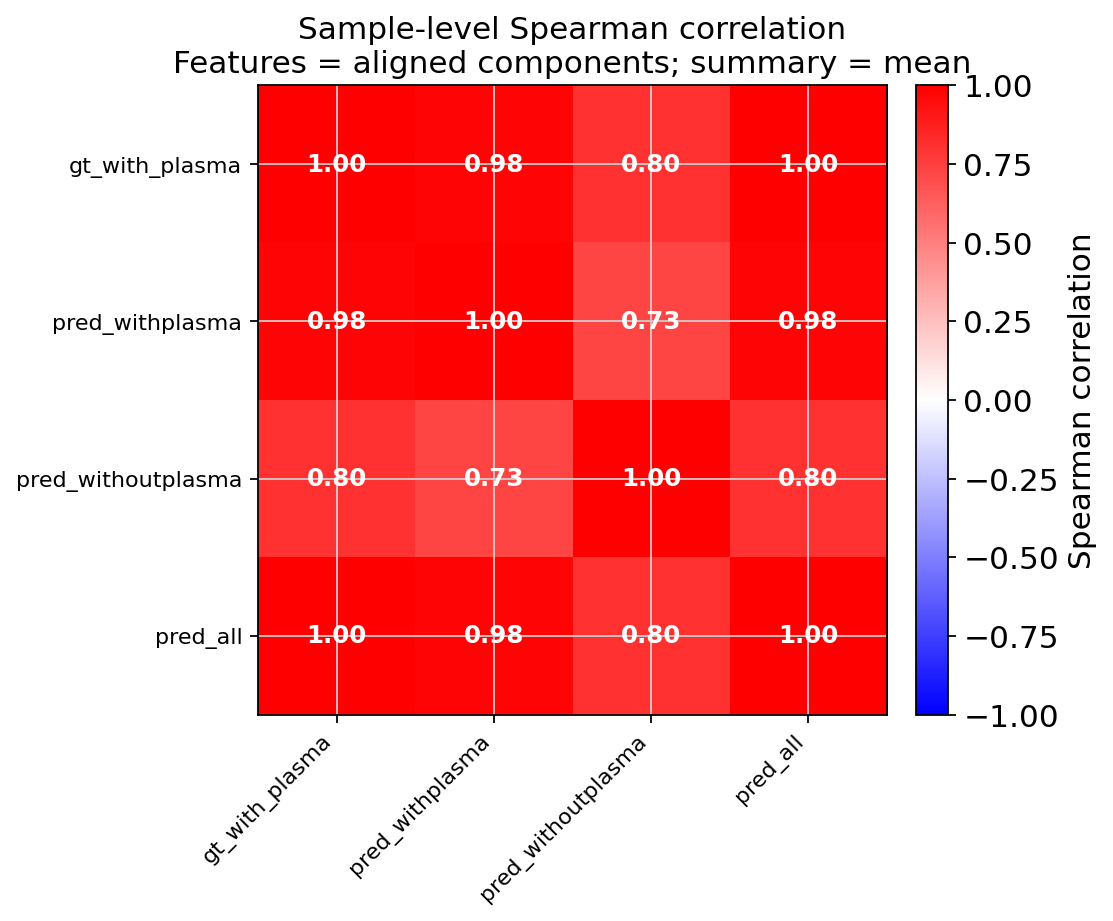

In [26]:
# ---------------------------
# 10) Heatmap: blue-white-red
# ---------------------------
fig, ax = plt.subplots(figsize=(7, 6))

im = ax.imshow(
    sample_corr.values,
    cmap="bwr",   # blue-white-red
    vmin=-1,
    vmax=1,
    interpolation="nearest"
)

ax.set_xticks(range(sample_corr.shape[1]))
ax.set_xticklabels(
    sample_corr.columns,
    rotation=45,
    ha="right",
    fontsize=10
)

ax.set_yticks(range(sample_corr.shape[0]))
ax.set_yticklabels(
    sample_corr.index,
    fontsize=10
)

ax.set_title(
    f"Sample-level Spearman correlation\n"
    f"Features = aligned components; summary = {GROUP_SUMMARY_METHOD}"
)

# text labels
for i in range(sample_corr.shape[0]):
    for j in range(sample_corr.shape[1]):
        val = sample_corr.iloc[i, j]
        if np.isfinite(val):
            ax.text(
                j,
                i,
                f"{val:.2f}",
                ha="center",
                va="center",
                fontsize=11,
                color="white",
                fontweight="bold"
            )

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Spearman correlation")

plt.tight_layout()
plt.savefig(out_png, dpi=300, bbox_inches="tight")
plt.savefig(out_pdf, bbox_inches="tight")
plt.show()